In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [11]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=1, shape="triangle"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

irradiance=2.5
wavelength=640
bleaching=True
energy_transfer=True
reducing_agent="mea"
concentration=100
ph=7.5


In [14]:
transitions = fluorophore_system.load_transitions(
    irradiance=irradiance,
    wavelength=wavelength,
    bleaching=bleaching,
    energy_transfer=energy_transfer,
    dstorm=True,
    dstorm_parameters={'reducing_agent':reducing_agent,
    'concentration':concentration,
    'ph':ph},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates({5:2e4, 4:1e7})
transition_set.finalize()

In [16]:
rng = np.random.default_rng(1)

In [17]:
predict = pr.Prediction(transition_set)

WARNING for line: predict = pr.Prediction(transition_set)
 absorbing states have a lifetime of inf and a frequency / occupation of 0. Absorbing transitions have a frequency of 0. 


In [18]:
simulation = si.Simulation(transition_set)
simulation.run(size=1e7, seed=rng)

WARNING for line:         ax.set_yscale(yscale)
 Data has no positive values, and therefore cannot be log-scaled. 
WARNING for line:         ax.set_xscale(xscale)
 Data has no positive values, and therefore cannot be log-scaled. 


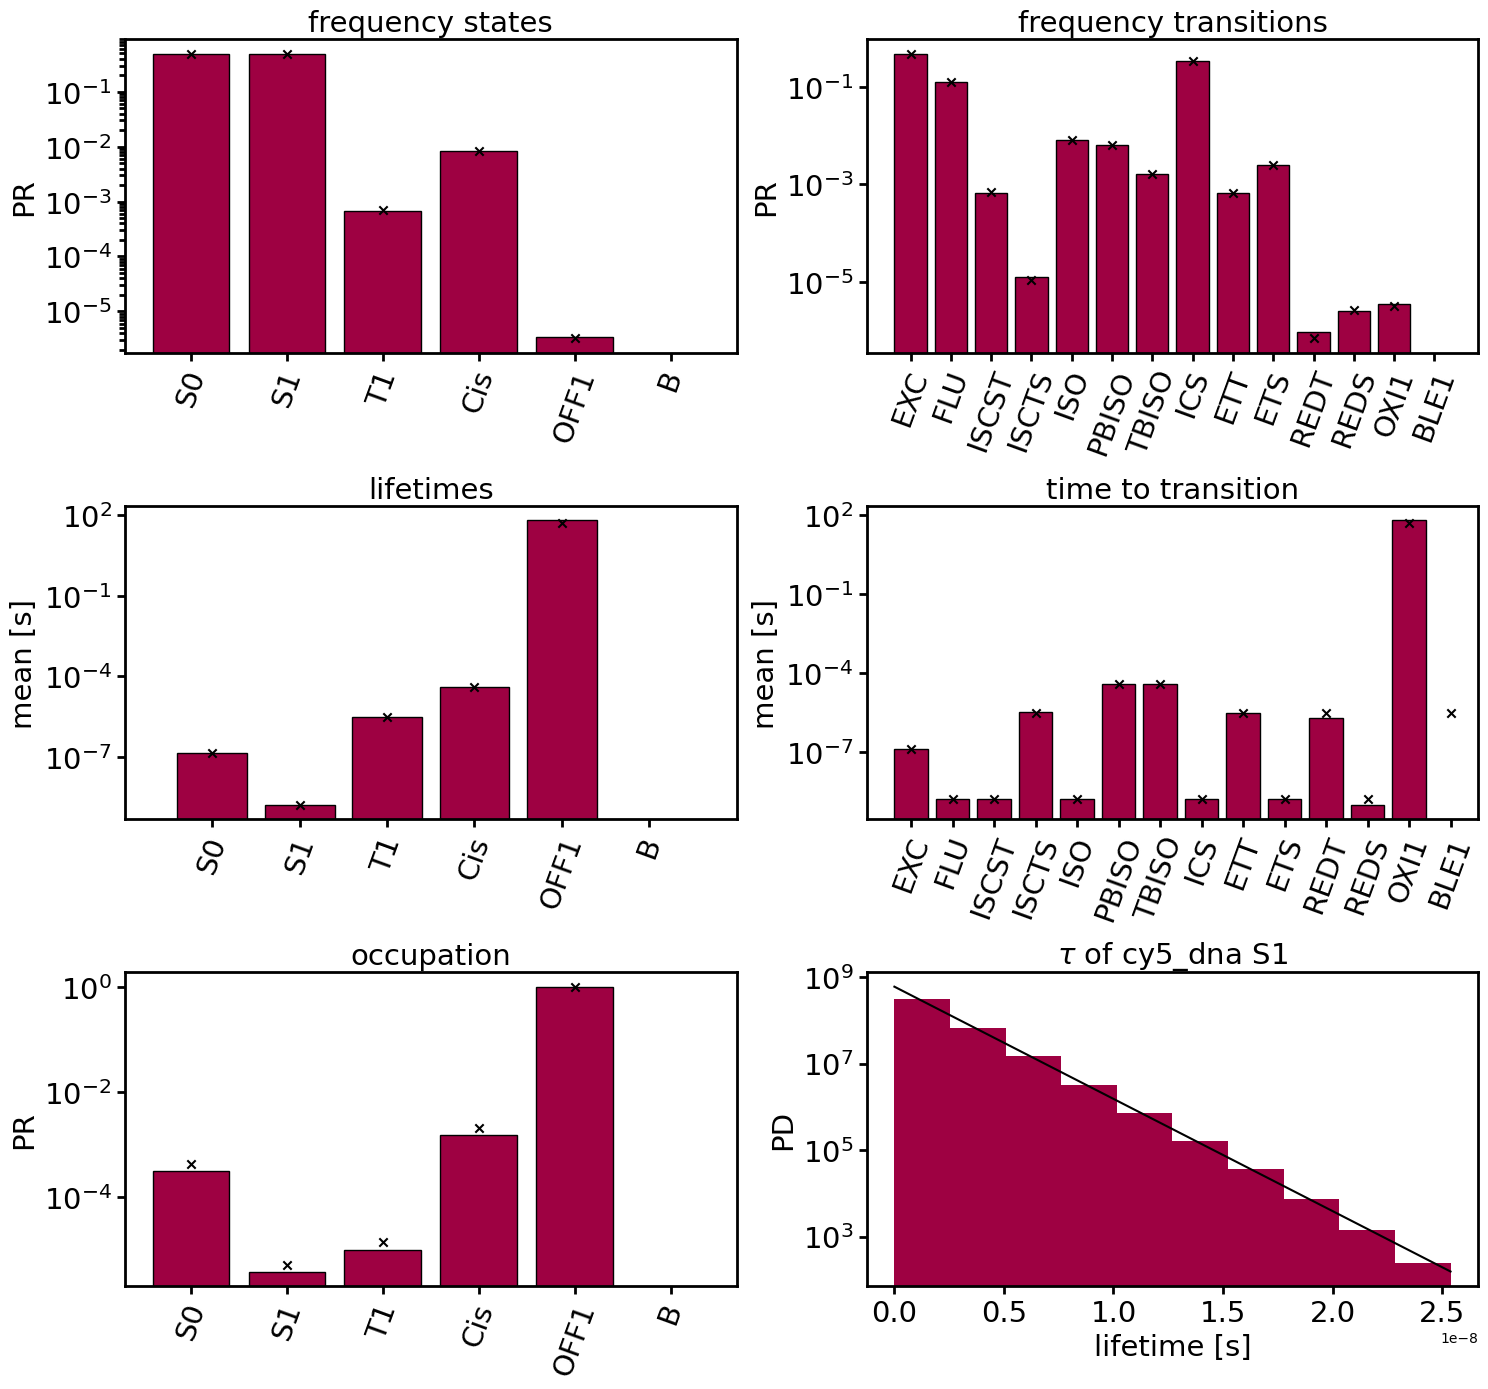

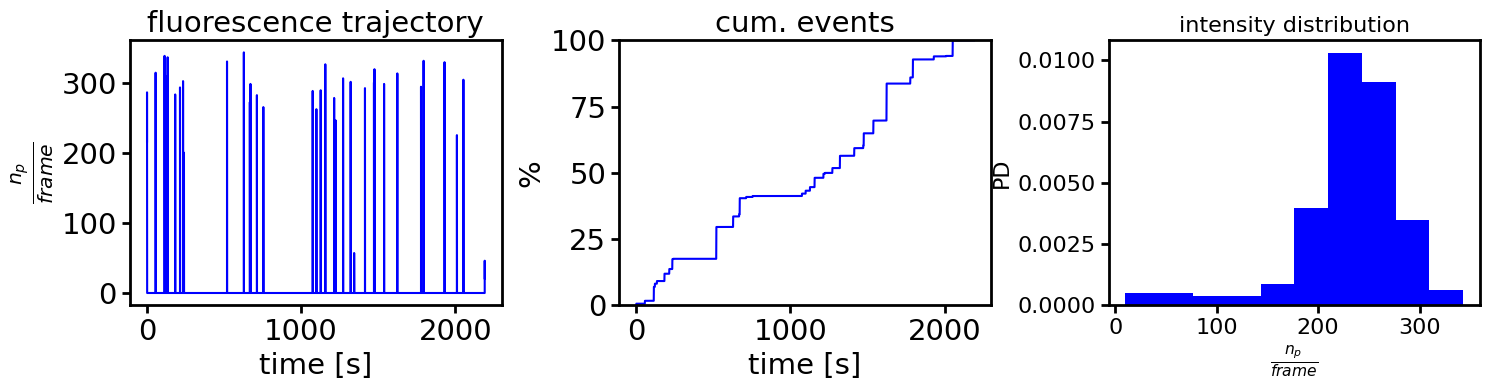

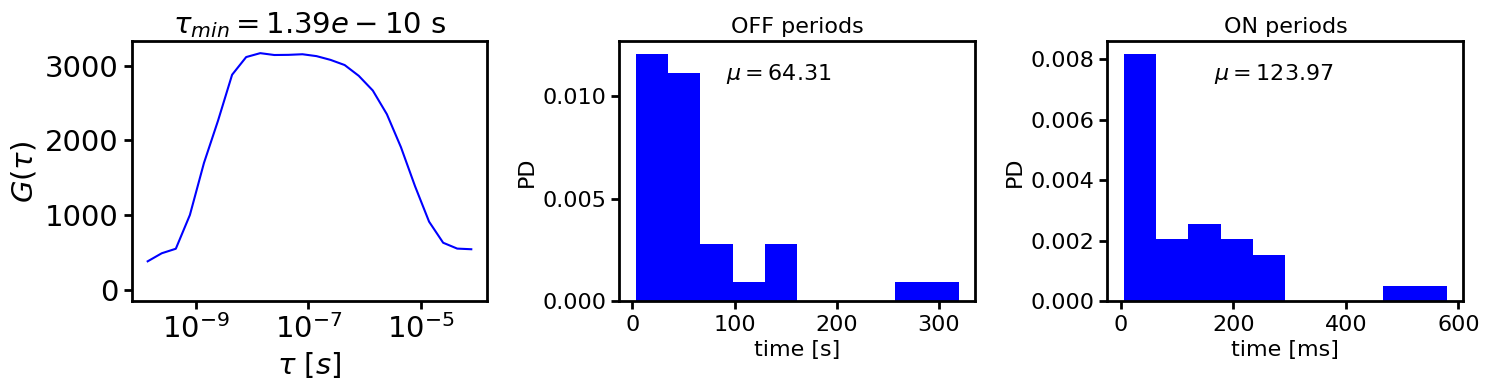

In [22]:
analysis = an.Analysis(simulation)
ax = fi.universal_figure(nrows=3, ncols=2, fig_height=14, fig_width=15)
analysis.plot_frequency_states(legend=False, axes=ax[0, 0], prediction=predict)
analysis.plot_frequency_transitions(legend=False, axes=ax[0, 1], prediction=predict)
analysis.plot_state_occupations(legend=False, axes=ax[2, 0], prediction=predict)
analysis.plot_mean_lifetimes(legend=False, axes=ax[1, 0], prediction=predict)
analysis.plot_mean_transition_times(legend=False, axes=ax[1, 1], prediction=predict)
analysis.plot_lifetime_distributions(legend=False, state_identity=1, axes=ax[2, 1], prediction=predict, 
                                     fluorophore='cy5_dna', color=(0.6196078431372549, 0.00392156862745098, 0.25882352941176473, 1.0))
fig = mi.get_figure(ax)
fig.tight_layout()
fig.savefig("1fstats.svg")

ax = fi.universal_figure(nrows=1, ncols=3, fig_height=4, fig_width=15)
emis = em.Emissions(frame_time="5ms", bandpass=[665, 731], seed=rng)
emis.extract(simulation)
photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
emis.add_transmittance(p=0.99, seed=rng) # lens 1
emis.add_transmittance(p=0.99, seed=rng) # lens 2
emis.add_quantum_efficiency(p=0.85, seed=rng)
emis.add_poisson_noise(rate=0.6, seed=rng)
emis.apply_threshold(threshold=10)
emis.plot_time_series(axes=ax[0, 0])
emis.plot_cumulative_events(axes=ax[0, 1])
emis.plot_histogram(axes=ax[0, 2])
fig = mi.get_figure(ax)
fig.tight_layout()
fig.savefig("1femissions.svg")

ax = fi.universal_figure(nrows=1, ncols=3, fig_height=4, fig_width=15)
fcs = fcs_p.FCS(emis)
fcs.autocorrelate_time_points(
    exp_min=-10, exp_max=-4, points_per_base=4, base=10, normalize=True
)
fcs.plot(axes=ax[0, 0], unit="s")
blink = bl.Blinking(emis)
blink.plot(mode='off_histogram', axes=ax[0, 1], as_time='s')
blink.plot(mode='on_histogram', axes=ax[0, 2], as_time='ms')
fig = mi.get_figure(ax)
fig.tight_layout()

fig.savefig("1fanalyses.svg")

### Photoswitching fingerprint

In [12]:
num_simulations = 100

In [25]:
all_events_summed = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))

for i in range(num_simulations):
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, seed=rng, end_time=300)
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    emis.extract(simulation)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
    emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
    emis.add_transmittance(p=0.99, seed=rng) # lens 1
    emis.add_transmittance(p=0.99, seed=rng) # lens 2
    emis.add_quantum_efficiency(p=0.85, seed=rng)
    emis.add_poisson_noise(rate=0.6, seed=rng)
    emis.apply_threshold(threshold=10)
    all_events_summed = all_events_summed + emis.event_time_series.values

In [28]:
rel_all_events = all_events_summed.cumsum() / all_events_summed.sum()
rel_all_events_discard = all_events_summed.iloc[300:].cumsum() / all_events_summed.iloc[300:].sum()

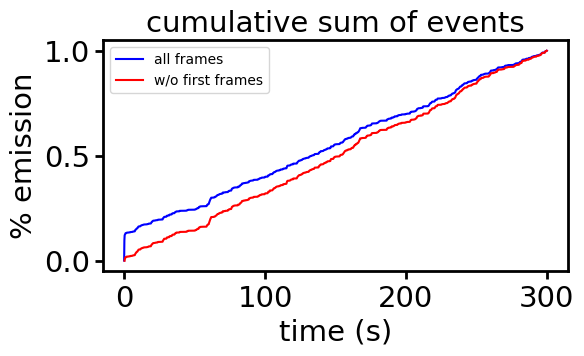

In [32]:
ax = fi.universal_figure(data=[all_events_summed.index, rel_all_events], 
                        label='all frames')
fi.universal_figure(data=[all_events_summed.index[300:], rel_all_events_discard], 
                    title='cumulative sum of events', ylabel='% emission', xlabel='time (s)', 
                    axes=ax[0], color='r', label='w/o first frames', legend=True)
fig = mi.get_figure(ax)
fig.savefig("1fcum_locs.svg")